In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
import ssam_plot as splot
from ssam_groups import cohorts
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
affected_boxes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 60, 33, 66]

### Define scenario and control files

In [3]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2019-2022/outputSalishSeaCATCH.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [10]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('*0FC90*/outputSalishSeaCATCH.nc')])
for path in scenario_paths:
    print(path.parent.stem)

highres-2019-2022_5b_1_2019-01-20_0FC90_6718
highres-2019-2022_5b_1_2019-01-20_0FC90_6719
highres-2019-2022_5b_1_2019-01-20_0FC90_AT


In [11]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [6]:
# start and end time of data display, after burn-in
start = 0
end = time.size

In [7]:
def compare_scenario_catch(variable, box):
    fig, ax = plt.subplots(figsize = (14,3))
    names = []
    for scenario, path in zip(scenario_datasets, scenario_paths):
        names.append(path.parent.stem)
        catch = scenario.variables[variable+'_Catch'][:,box]
        time = scenario.variables['t']
        ax.plot(time, catch)
    ax.legend(names)
    ax.set_ylabel(variable + ' Catch (#)')

In [8]:
def compare_cohort_catch(bio_group, scenario, name, boxes):
    label_size = 11
    font_size = 12
    line_width = 2

    time = scenario.variables['t']

    for species in bio_group:

        fig, ax = plt.subplots(figsize = (14,3))
        #ax.plot(event_start, 0, 'ok')

        numCohorts = cohorts[bio_group[species]]+1

        for cohort in range (1, numCohorts):

            new_species = bio_group[species] + str(cohort)
            catch_tb = scenario.variables[new_species + '_Catch'][:,boxes]
            catch = (catch_tb.sum(axis=1))
            ax.plot(time, catch, linewidth = line_width)
    
        ax.set_title(name, fontsize = font_size)
        ax.tick_params(labelsize=label_size)
        ax.set_ylabel(str(bio_group[species]) + ' Catch (#)')
        ax.legend(['cohort 1','cohort 2','cohort 3','cohort 4','cohort 5','cohort 6','cohort 7','cohort 8','cohort 9','cohort 10',]) #loc='center left'

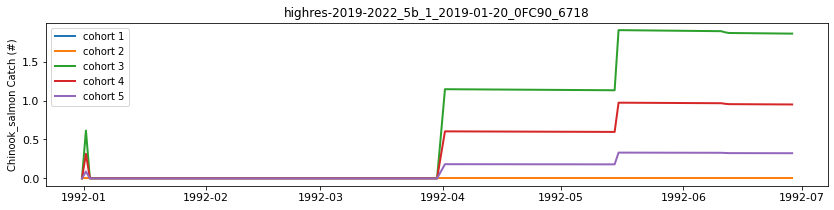

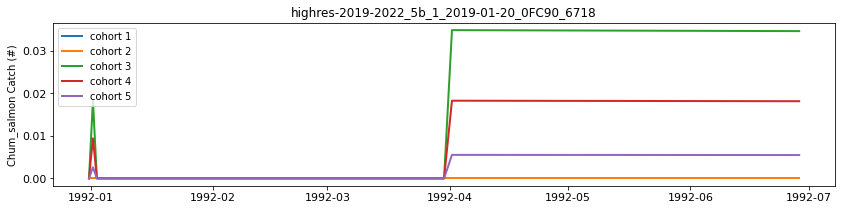

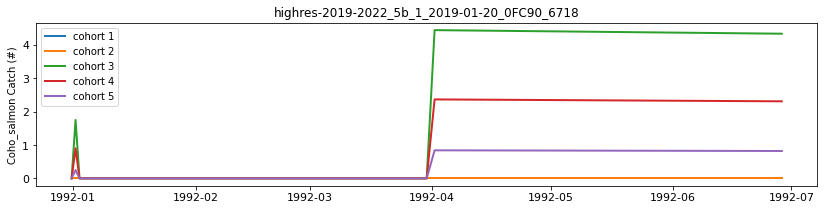

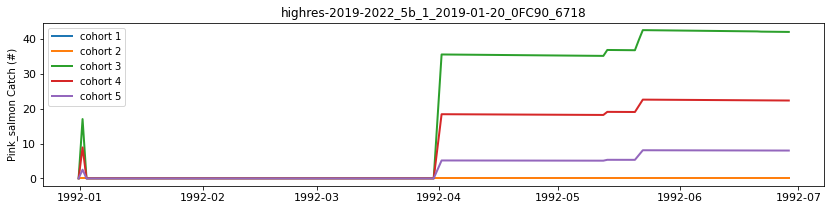

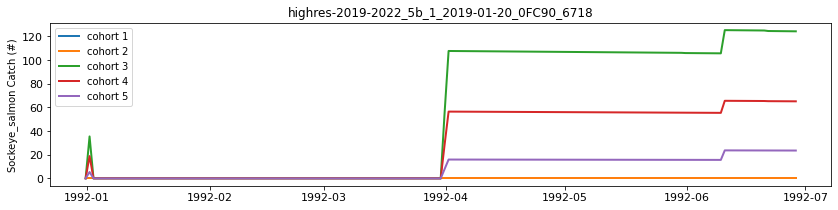

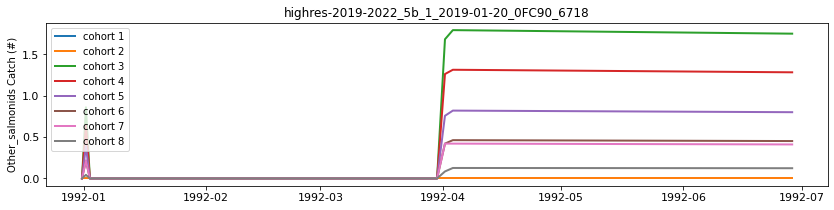

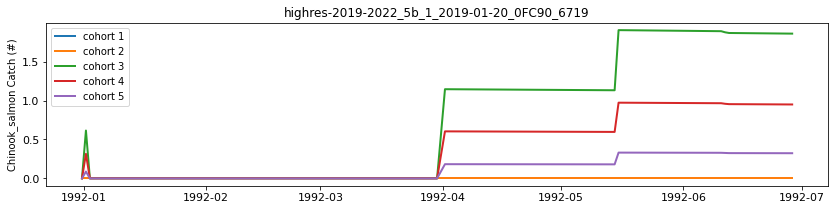

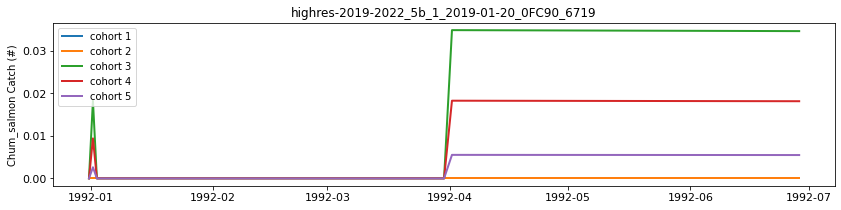

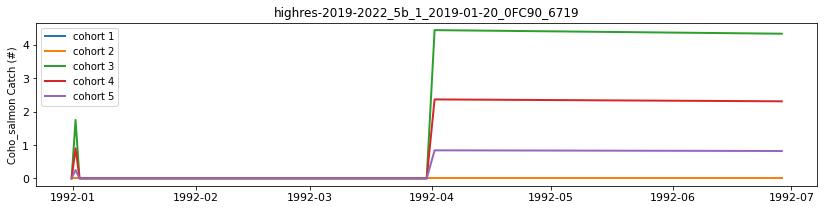

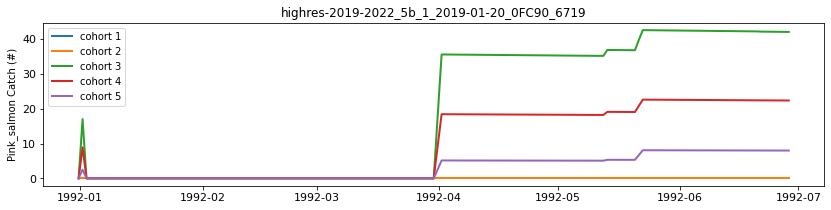

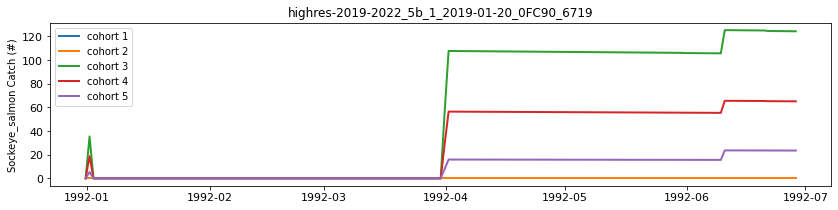

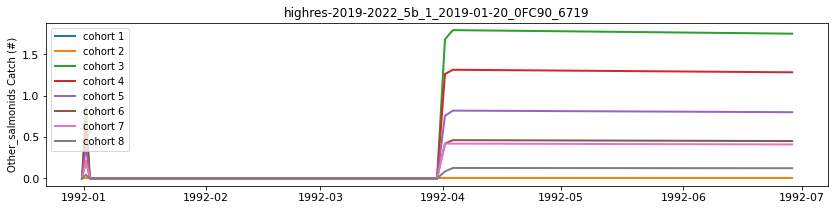

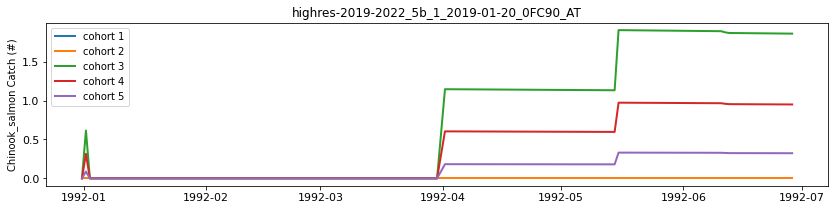

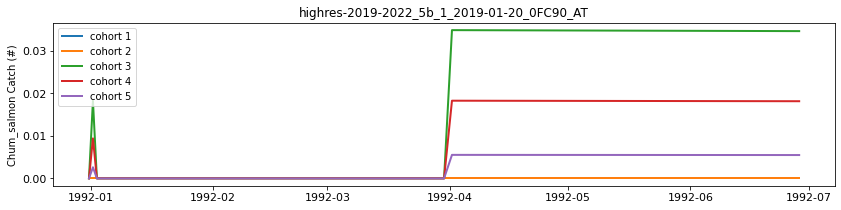

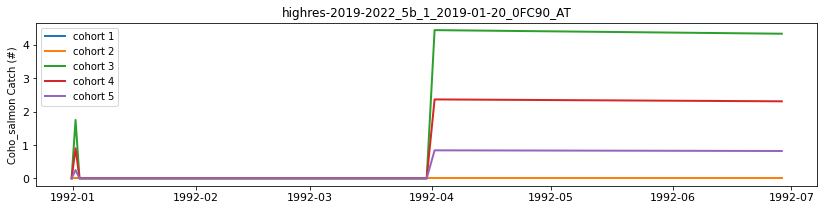

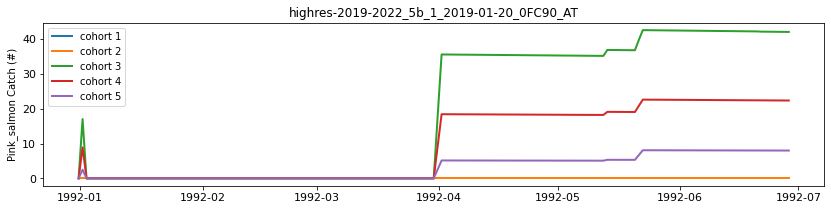

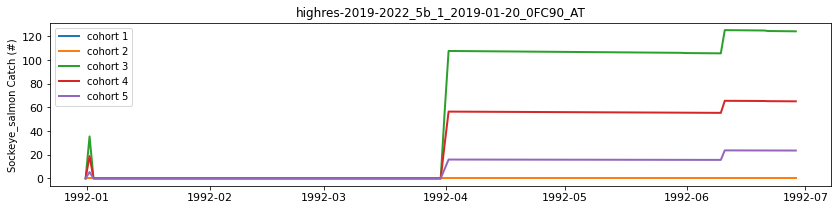

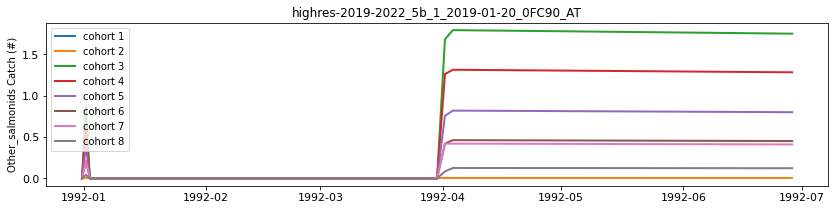

In [12]:
for scenario, path in zip(scenario_datasets, scenario_paths):
    compare_cohort_catch(groups.wild_salmon, scenario, path.parent.stem, affected_boxes)

In [15]:
def aggregate_boxplot_data_pelagic(bio_group, bio_group_name, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '5 years later', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+nm[2]
            hex_colour = '#863092'
            control = control_73
            if '2019'in year:
                end_days = days2019summer_73
            else: 
                end_days = days2020summer_73
            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+nm[2]
            hex_colour = '#6DB48E'
            control = control_90
            if '2019'in year:
                end_days = days2019winter_90
            else:
                end_days = days2020winter_90
        elif nm[1] == '6a':
            scenario_name = 'EB-'+nm[2]
            hex_colour = '#2F61A4'
            control = control_90
            if '2019'in year:
                end_days = days2019summer_90
            else:
                end_days = days2020summer_90
        elif nm[1] == '7a':
            scenario_name = 'JF-'+nm[2]
            hex_colour = '#A27170'
            control = control_73
            if '2019'in year:
                end_days = days2019winter_73
            else: 
                end_days = days2020winter_73

        # if '2019-01'in year:
        #     end_days = days2019winter
        # elif '2020-01' in year:
        #     end_days = days2020winter
        # elif '2019-07' in year:
        #     end_days = days2019summer
        # elif '2020-07' in year:
        #     end_days = days2020summer

        results = []
        for day in end_days: 
            start = day - 30
            p_oiled = 0
            p_control = 0
            for species in bio_group: 
                p_oiled = p_oiled + np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:day, location, 0:6], np.nan)
                p_control = p_control + np.ma.filled(control.variables[bio_group[species] + '_N'][start:day, location, 0:6], np.nan)
            
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()
            p_control = p_control.sum(axis=(1, 2)).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            results.append(p_ratio)
            
        for label, value in zip(data_labels, results):
            all_results.append({
            'bio_group': bio_group_name,
            'time_label': label,
            'scenario': scenario_name,
            'percent_change': value,
            'sensitivity': sensitivity[bio_group_name],
            'sensitivity_negative': -sensitivity[bio_group_name],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated-data-"+bio_group_name+".csv")

In [22]:
def aggregate_boxplot_data_vertebrates(bio_group, bio_group_name, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '5 years later', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+nm[2]
            hex_colour = '#863092'
            control = control_73
            if '2019'in year:
                end_days = days2019summer_73
            else: 
                end_days = days2020summer_73
            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+nm[2]
            hex_colour = '#6DB48E'
            control = control_90
            if '2019'in year:
                end_days = days2019winter_90
            else:
                end_days = days2020winter_90
        elif nm[1] == '6a':
            scenario_name = 'EB-'+nm[2]
            hex_colour = '#2F61A4'
            control = control_90
            if '2019'in year:
                end_days = days2019summer_90
            else:
                end_days = days2020summer_90
        elif nm[1] == '7a':
            scenario_name = 'JF-'+nm[2]
            hex_colour = '#A27170'
            control = control_73
            if '2019'in year:
                end_days = days2019winter_73
            else: 
                end_days = days2020winter_73

        # if '2019-01'in year:
        #     end_days = days2019winter
        # elif '2020-01' in year:
        #     end_days = days2020winter
        # elif '2019-07' in year:
        #     end_days = days2019summer
        # elif '2020-07' in year:
        #     end_days = days2020summer

        results = []
        for day in end_days: 
            aggregate_ratio = 0
            start = day - 30
            for species in bio_group:

                species_ratio = 0

                numCohorts = groups.cohorts[bio_group[species]]
                for cohort in range (1, numCohorts+1):
                    new_species = bio_group[species] + str(cohort)
                
                    o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:day, location, 0:6], np.nan)
                    o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:day, location, 0:6], np.nan)
                    o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:day, location, 0:6], np.nan)

                    c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:day, location, 0:6], np.nan)
                    c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:day, location, 0:6], np.nan)
                    c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:day, location, 0:6], np.nan)

                    o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                    o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                    c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                    c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                    cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                    #print(scenario_name, species, cohort, cohort_ratio)
                    species_ratio = species_ratio + cohort_ratio

                final_species_ratio = species_ratio/numCohorts
                #print(scenario_name, species, final_species_ratio)
                aggregate_ratio = aggregate_ratio + final_species_ratio
            
            results.append(aggregate_ratio/len(bio_group))
            #print(scenario_name, bio_group_name, aggregate_ratio, aggregate_ratio/len(bio_group))
            
        for label, value in zip(data_labels, results):
            all_results.append({
            'bio_group': bio_group_name,
            'time_label': label,
            'scenario': scenario_name,
            'percent_change': value,
            'sensitivity': sensitivity[bio_group_name],
            'sensitivity_negative': -sensitivity[bio_group_name],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated-data-"+bio_group_name+".csv")

In [39]:
def aggregate_boxplot_data_benthic(bio_group, bio_group_name, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '5 years later', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+nm[2]
            hex_colour = '#863092'
            control = control_73
            #location = affected_boxes['AP']
            if '2019'in year:
                end_days = days2019summer_73
            else: 
                end_days = days2020summer_73
            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+nm[2]
            hex_colour = '#6DB48E'
            control = control_90
            #location = affected_boxes['TP']
            if '2019'in year:
                end_days = days2019winter_90
            else:
                end_days = days2020winter_90
        elif nm[1] == '6a':
            scenario_name = 'EB-'+nm[2]
            hex_colour = '#2F61A4'
            control = control_90
            #location = affected_boxes['EB']
            if '2019'in year:
                end_days = days2019summer_90
            else:
                end_days = days2020summer_90
        elif nm[1] == '7a':
            scenario_name = 'JF-'+nm[2]
            hex_colour = '#A27170'
            control = control_73
            #location = affected_boxes['JF']
            if '2019'in year:
                end_days = days2019winter_73
            else: 
                end_days = days2020winter_73

        # if '2019-01'in year:
        #     end_days = days2019winter
        # elif '2020-01' in year:
        #     end_days = days2020winter
        # elif '2019-07' in year:
        #     end_days = days2019summer
        # elif '2020-07' in year:
        #     end_days = days2020summer

        results = []
        for day in end_days: 
            start = day - 30
            p_oiled = 0
            p_control = 0
            for species in bio_group: 
                p_oiled = p_oiled + np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:day, location], np.nan)
                p_control = p_control + np.ma.filled(control.variables[bio_group[species] + '_N'][start:day, location], np.nan)
            
            p_oiled = p_oiled.sum(axis=1).mean()
            p_control = p_control.sum(axis=1).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            results.append(p_ratio)
            
        for label, value in zip(data_labels, results):
            all_results.append({
            'bio_group': bio_group_name,
            'time_label': label,
            'scenario': scenario_name,
            'percent_change': value,
            'sensitivity': sensitivity[bio_group_name],
            'sensitivity_negative': -sensitivity[bio_group_name],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated-data-"+bio_group_name+".csv")

In [16]:
aggregate_boxplot_data_pelagic(plankton, 'plankton')

In [40]:
aggregate_boxplot_data_benthic(groups.benthic_invertebrates, 'benthic_invertebrates')

In [25]:
aggregate_boxplot_data_benthic(groups.macroalgae, 'marine_plants')

In [26]:
aggregate_boxplot_data_vertebrates(groups.salmon, 'salmon')

In [27]:
aggregate_boxplot_data_vertebrates(demersal_fish, 'demersal_fish')

In [28]:
aggregate_boxplot_data_vertebrates(pelagic_fish, 'pelagic_fish')

In [29]:
aggregate_boxplot_data_vertebrates(cetaceans, 'cetaceans')

In [30]:
aggregate_boxplot_data_vertebrates(pinnipeds, 'pinnipeds')

In [31]:
aggregate_boxplot_data_vertebrates(groups.sharks, 'elasmobranchs')

In [32]:
aggregate_boxplot_data_vertebrates(groups.birds, 'seabirds')

In [41]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/')
results_paths = sorted([p for p in results_root.glob('aggregated-data-*.csv')])
aggregated_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    aggregated_data.append(df1[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])

aggregated_data_df = pd.concat(aggregated_data, ignore_index=True)
aggregated_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated_data.csv")

In [42]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI-1/aggregated_data.csv")

In [43]:
code_names = {'EB','AP','JF','TP'}

In [44]:
time_labels = df['time_label'].unique()
scenarios = df['scenario'].unique()
bio_groups = ['seabirds','marine_plants','benthic_invertebrates','demersal_fish', 'elasmobranchs', 'cetaceans','pinnipeds', 'salmon', 'pelagic_fish', 'plankton'] #df['bio_group'].unique()

hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
colors = plt.cm.tab10.colors


In [ ]:
x_lim = [-12, 15]
for code_name in code_names:
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
            n_rows = n_rows
    n_cols = len(time_labels)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, n_rows), sharey=True)

    if n_cols == 1:
        axes = [axes]  

    if code_name == 'AP':
        hex_colour = '#863092'
    elif code_name == 'TP':
        hex_colour = '#6DB48E'
    elif code_name == 'EB':
        hex_colour = '#2F61A4'
    elif code_name == 'JF':
        hex_colour = '#A27170'
    
    these_scenarios = [code_name+'-1',code_name+'-2',code_name+'-3',code_name+'-4']

    bar_width = 0.8 / len(these_scenarios)  
    y_pos = np.arange(len(bio_groups))

    for i, time in enumerate(time_labels):
        ax = axes[i]
        for j, scenario in enumerate(these_scenarios):
            df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
            df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
            offset = (j - len(these_scenarios)/2) * bar_width + bar_width/2

            ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
        ax.barh(bio_groups, df_plot['sensitivity'], label=scenario, color='grey', alpha=0.3)
        ax.barh(bio_groups, df_plot['sensitivity_negative'], label=scenario, color='grey', alpha=0.3)
        ax.xaxis.grid(True)
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels, fontsize=20)
    
        ax.set_title(time, fontsize=20)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(bio_groups, fontsize=20) 
        ax.set_xlim(x_lim)
        ax.set_xlabel("Percent Change", fontsize=20)

    fig.legend(these_scenarios, loc='upper center', ncol=len(these_scenarios), fontsize=18) 
    plt.show()

For presentations

In [ ]:
x_lim = [-12,15]
for code_name in code_names:
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
            n_rows = n_rows
    n_cols = len(time_labels)
    fig, axes = plt.subplots(1, n_cols, figsize=(10, 3), sharey=True)

    if n_cols == 1:
        axes = [axes]  

    if code_name == 'AP':
        hex_colour = '#863092'
    elif code_name == 'TP':
        hex_colour = '#6DB48E'
    elif code_name == 'EB':
        hex_colour = '#2F61A4'
    elif code_name == 'JF':
        hex_colour = '#A27170'
    
    these_scenarios = [code_name+'-1',code_name+'-2',code_name+'-3',code_name+'-4']

    bar_width = 0.9 / len(these_scenarios)  
    y_pos = np.arange(len(bio_groups))

    for i, time in enumerate(time_labels):
        ax = axes[i]
        for j, scenario in enumerate(these_scenarios):
            df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
            df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
            offset = (j - len(these_scenarios)/2) * bar_width + bar_width/2

            ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
        ax.barh(bio_groups, df_plot['sensitivity'], label=scenario, color='grey', alpha=0.3)
        ax.barh(bio_groups, df_plot['sensitivity_negative'], label=scenario, color='grey', alpha=0.3)
        ax.xaxis.grid(True)
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels, fontsize=14)
    
        ax.set_title(time, fontsize=16)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(bio_groups, fontsize=16) 
        ax.set_xlim(x_lim)
        #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(these_scenarios, ncol=len(these_scenarios), bbox_to_anchor=(0.8, 1.2), fontsize=16) 
    plt.show()